# Map ABoVE domain and Canada for Meta-analysis of AGB paper

refs:
+ lvis_footprints_geo.ipynb
+ above_lidar_check.ipynb
+ s3_data_access_LVIS.ipynb
+ arcticdem_stac_api_workflow.ipynb

library(tidyverse)
library(sf)
library(ggspatial)
library(terra)

In [33]:
library(patchwork)

In [34]:
library(RColorBrewer)
library(viridis)
library(ggspatial)

In [35]:
MAINDIR = '/projects/my-public-bucket/above_agb_metaanalysis'
DATADIR = paste0(MAINDIR,'/data')
OUTDIR = paste0(MAINDIR,'/paper_figs')

In [36]:
source('/projects/code/3dsi/boreal_map_functions.R')

[1] "MAAP"
[1] "MAAP"


In [88]:
plots_testing = st_read(paste0(DATADIR,'/AGB_all_test_plots.geojson')) %>% st_transform(crs = crs_canalb)

Reading layer `AGB_all_test_plots' from data source 
  `/projects/my-public-bucket/above_agb_metaanalysis/data/AGB_all_test_plots.geojson' 
  using driver `GeoJSON'
Simple feature collection with 1832 features and 5 fields
Geometry type: POINT
Dimension:     XY
Bounding box:  xmin: -3088668 ymin: 413363.3 xmax: 2931819 ymax: 4165501
Projected CRS: North_America_Equidistant_Conic


In [89]:
levels(factor(plots_testing$Group))

[1] "2010 maps"   "2020 maps"   "Matasci"     "Tundra 2020" "Wang"

In [90]:
plots_testing$Group = factor(plots_testing$Group)
levels(plots_testing$Group) = c('2010s (boreal)', '2020s (boreal)', 'Matasci et al.', '2020s (tundra)', 'Wang et al.')

In [91]:
#levels(factor(plots_testing$Group)) = c('2010s boreal maps', '2020s boreal maps', 'Matasci et al.', '2020s tundra maps', 'Wang et al.')
levels(plots_testing$Group)

[1] "2010s (boreal)" "2020s (boreal)" "Matasci et al." "2020s (tundra)"
[5] "Wang et al."

In [92]:
tail(plots_testing)

,Group,meas_year,Longitude,Latitude,Test_plot_by_map_group,geometry
,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<POINT [m]>
1827,2020s (tundra),NA,-74.91248,70.40157,"Tundra, 2020",POINT (377065.2 3420014)
1828,2020s (tundra),NA,-74.89386,70.40307,"Tundra, 2020",POINT (377730.9 3420284)
1829,2020s (tundra),NA,-74.89670,70.40292,"Tundra, 2020",POINT (377628.1 3420252)
1830,2020s (tundra),NA,-74.91367,70.40308,"Tundra, 2020",POINT (376995.9 3420174)
1831,2020s (tundra),NA,-74.79385,70.46580,"Tundra, 2020",POINT (380383.3 3427754)
1832,2020s (tundra),NA,-74.79887,70.46607,"Tundra, 2020",POINT (380192.8 3427755)


In [41]:
#plots_testing[which(plots_testing$Group == 'Tundra 2020'),c('Group')] = 'Lara et al.'

In [42]:
# plots_testing[which(plots_testing$Group == 'Matasci'),c('Group')] = 'Matasci et al.'
# plots_testing[which(plots_testing$Group == 'Wang'),c('Group')] = 'Wang et al.'

In [43]:
ecoregions = st_read(paste0(DATADIR,'/Ecoregion_Level1.geojson')) %>% st_transform(crs = crs_canalb)

Reading layer `Ecoregion_Level1' from data source 
  `/projects/my-public-bucket/above_agb_metaanalysis/data/Ecoregion_Level1.geojson' 
  using driver `GeoJSON'
Simple feature collection with 8 features and 12 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3599604 ymin: 291190.8 xmax: 2975061 ymax: 4729863
Projected CRS: North_America_Equidistant_Conic


In [44]:
levels(factor(ecoregions$NA_L2NAME))

[1] "NORTHERN ARCTIC"

In [45]:
above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)

Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


In [46]:
crs_canalb = '+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-85 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs'

In [47]:
disp_win_wgs84 <- st_sfc(st_point(c(-125, 35)), st_point(c(-10, 75)), crs = 4326)
disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
disp_win_coord <- st_coordinates(disp_win_trans)

In [48]:
theme_custom = list(
      theme_minimal(),
          annotation_scale(location = "bl", style="ticks") ,
          annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    )

In [93]:
colnames(plots_testing)

[1] "Group"                  "meas_year"              "Longitude"             
[4] "Latitude"               "Test_plot_by_map_group" "geometry"

In [134]:
do_map_above_metaanalysis<- function(ABOVE_DOMAIN=False){
  
  boreal = st_read(wwf_circ_dis_fn) %>% st_transform(crs = crs_canalb)
  above_domain = st_read(above_domain_fn) %>% st_transform(crs = crs_canalb)
  world <- ne_countries(scale = "medium", returnclass = "sf")
  
  map = ggplot() + 
    
    geom_sf(data = st_as_sf(world) %>% filter(subregion == "Northern America") , size=0.1, fill='grey95')+ 
    #geom_sf(data = boreal, color=NA, fill="grey85") +
    geom_sf(data = st_as_sf(world) %>% filter(subregion == "Northern America"), fill=NA, size=0.1 ) +
    geom_sf(data = ecoregions, fill="grey75", color='white', linetype = "dashed", size=4)
  
  if(ABOVE_DOMAIN){
    map = map +
      geom_sf(data = above_domain, 
              #fill="grey60", 
              fill="grey80",
              color=NULL,
              #linetype = "dotted"
             )
  }
  
  return(map)
}

GET_CUSTOM_ABOVE_METANALYSIS_MAP <- function(
                                    disp_win_wgs84,
                                    crs_wgs84 = "+proj=longlat +datum=WGS84 +ellps=WGS84 +towgs84=0,0,0,0,0,0,0 +no_defs",
                                    crs_canalb = '+proj=aea +lat_1=50 +lat_2=70 +lat_0=40 +lon_0=-96 +x_0=0 +y_0=0 +ellps=GRS80 +datum=NAD83 +units=m +no_defs'
                                    ){
    # https://www.r-bloggers.com/2019/04/zooming-in-on-maps-with-sf-and-ggplot2/
    #disp_win_wgs84 <- st_sfc(st_point(c(-145, 35)), st_point(c(-40, 75)), crs = 4326)
    disp_win_trans <- st_transform(disp_win_wgs84, crs = crs_canalb)
    disp_win_coord <- st_coordinates(disp_win_trans)
    
    # Orig labels with ABoVE core and ABoVE extended domains
    #txt_wgs84 <- st_sfc(st_point(c(-125, 60)), st_point(c(-135, 62)), st_point(c(-110, 56)), crs = 4326) #-121.5, 52.75
    txt_wgs84 <- st_sfc(st_point(c(-127.5, 62)), st_point(c(-120, 58)), crs = 4326)
    txt_trans <- st_transform(txt_wgs84, crs = crs_canalb)
    txt_coord <- st_coordinates(txt_trans)

    #label_wgs84 <- st_sfc(st_point(c(-137, 66)), st_point(c(-132, 54.5)), crs = 4326) #-121.5, 52.75
    label_wgs84 <- st_sfc(st_point(c(-137, 66)), crs = 4326)
    label_trans <- st_transform(label_wgs84, crs = crs_canalb)
    label_coord <- st_coordinates(label_trans)

    add_theme_custom = list(
            theme_bw(),
            theme(legend.position = c(0.85 ,0.85), 
              legend.text=element_text(size=rel(0.9)), 
              #legend.background = element_blank(),
              legend.box.background = element_rect(colour = "black"),
              axis.title.x = element_blank(), 
              axis.title.y = element_blank(),
              axis.text = element_text(size = 12),
              axis.text.y = element_text(angle=90, hjust = 0.5)
              )
      )

    custom_map_above = list(
        geom_sf(data = plots_testing, aes(color=Group), alpha=0.5),
        #scale_color_brewer(palette = 'Tab20'),
        coord_sf(xlim = disp_win_coord[,'X'], ylim = disp_win_coord[,'Y'], crs = crs_canalb, expand = F),
        #annotation_scale(location = "bl", width_hint = 0.15) ,
        annotate(geom = "text", x = txt_coord[,'X'], y = txt_coord[,'Y'], 
                 label = c("E c o r e g i o n s",
                           "ABoVE study\ndomain"
                           #"ABoVE\ncore\ndomain"
                           #,"ABoVE\nextended\ndomain"
                          ), 
                 fontface = c("italic", "italic"
                              #, "italic"
                             ), 
                 color = c("grey90","grey30"
                           #,"black"
                          ), size = c(4,4.5
                                      #,3.5
                                     )) ,
        annotate(geom = "label", x = label_coord[,'X'], y = label_coord[,'Y'], 
                 label = c("Great Slave Lake\nstudy area"#, "Timber harvest\nstudy area"
                          ), 
                 fontface = c("italic"), 
                 color = c("black"), size = c(2.25), fill='white', color='white',alpha=0.5) ,
        add_theme_custom,
        labs(color='Reference plot use     ')
    )

    return(custom_map_above)
}

Reading layer `wwf_circumboreal_Dissolve' from data source 
  `/projects/my-public-bucket/databank/arc/wwf_circumboreal_Dissolve.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -5281040 ymin: -60527.9 xmax: 3959203 ymax: 8747447
Projected CRS: NAD83 / Alaska Albers
Reading layer `ABoVE_Study_Domain' from data source 
  `/projects/my-public-bucket/databank/arc/ABoVE_Study_Domain_Final/ABoVE_Study_Domain.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 2 features and 4 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: -3398275 ymin: 997535.1 xmax: 623682.7 ymax: 4562705
Projected CRS: Canada_Albers_Equal_Area_Conic


Warning message:
“Duplicated aesthetics after name standardisation: colour”
Coordinate system already present. Adding new coordinate system, which will
replace the existing one.


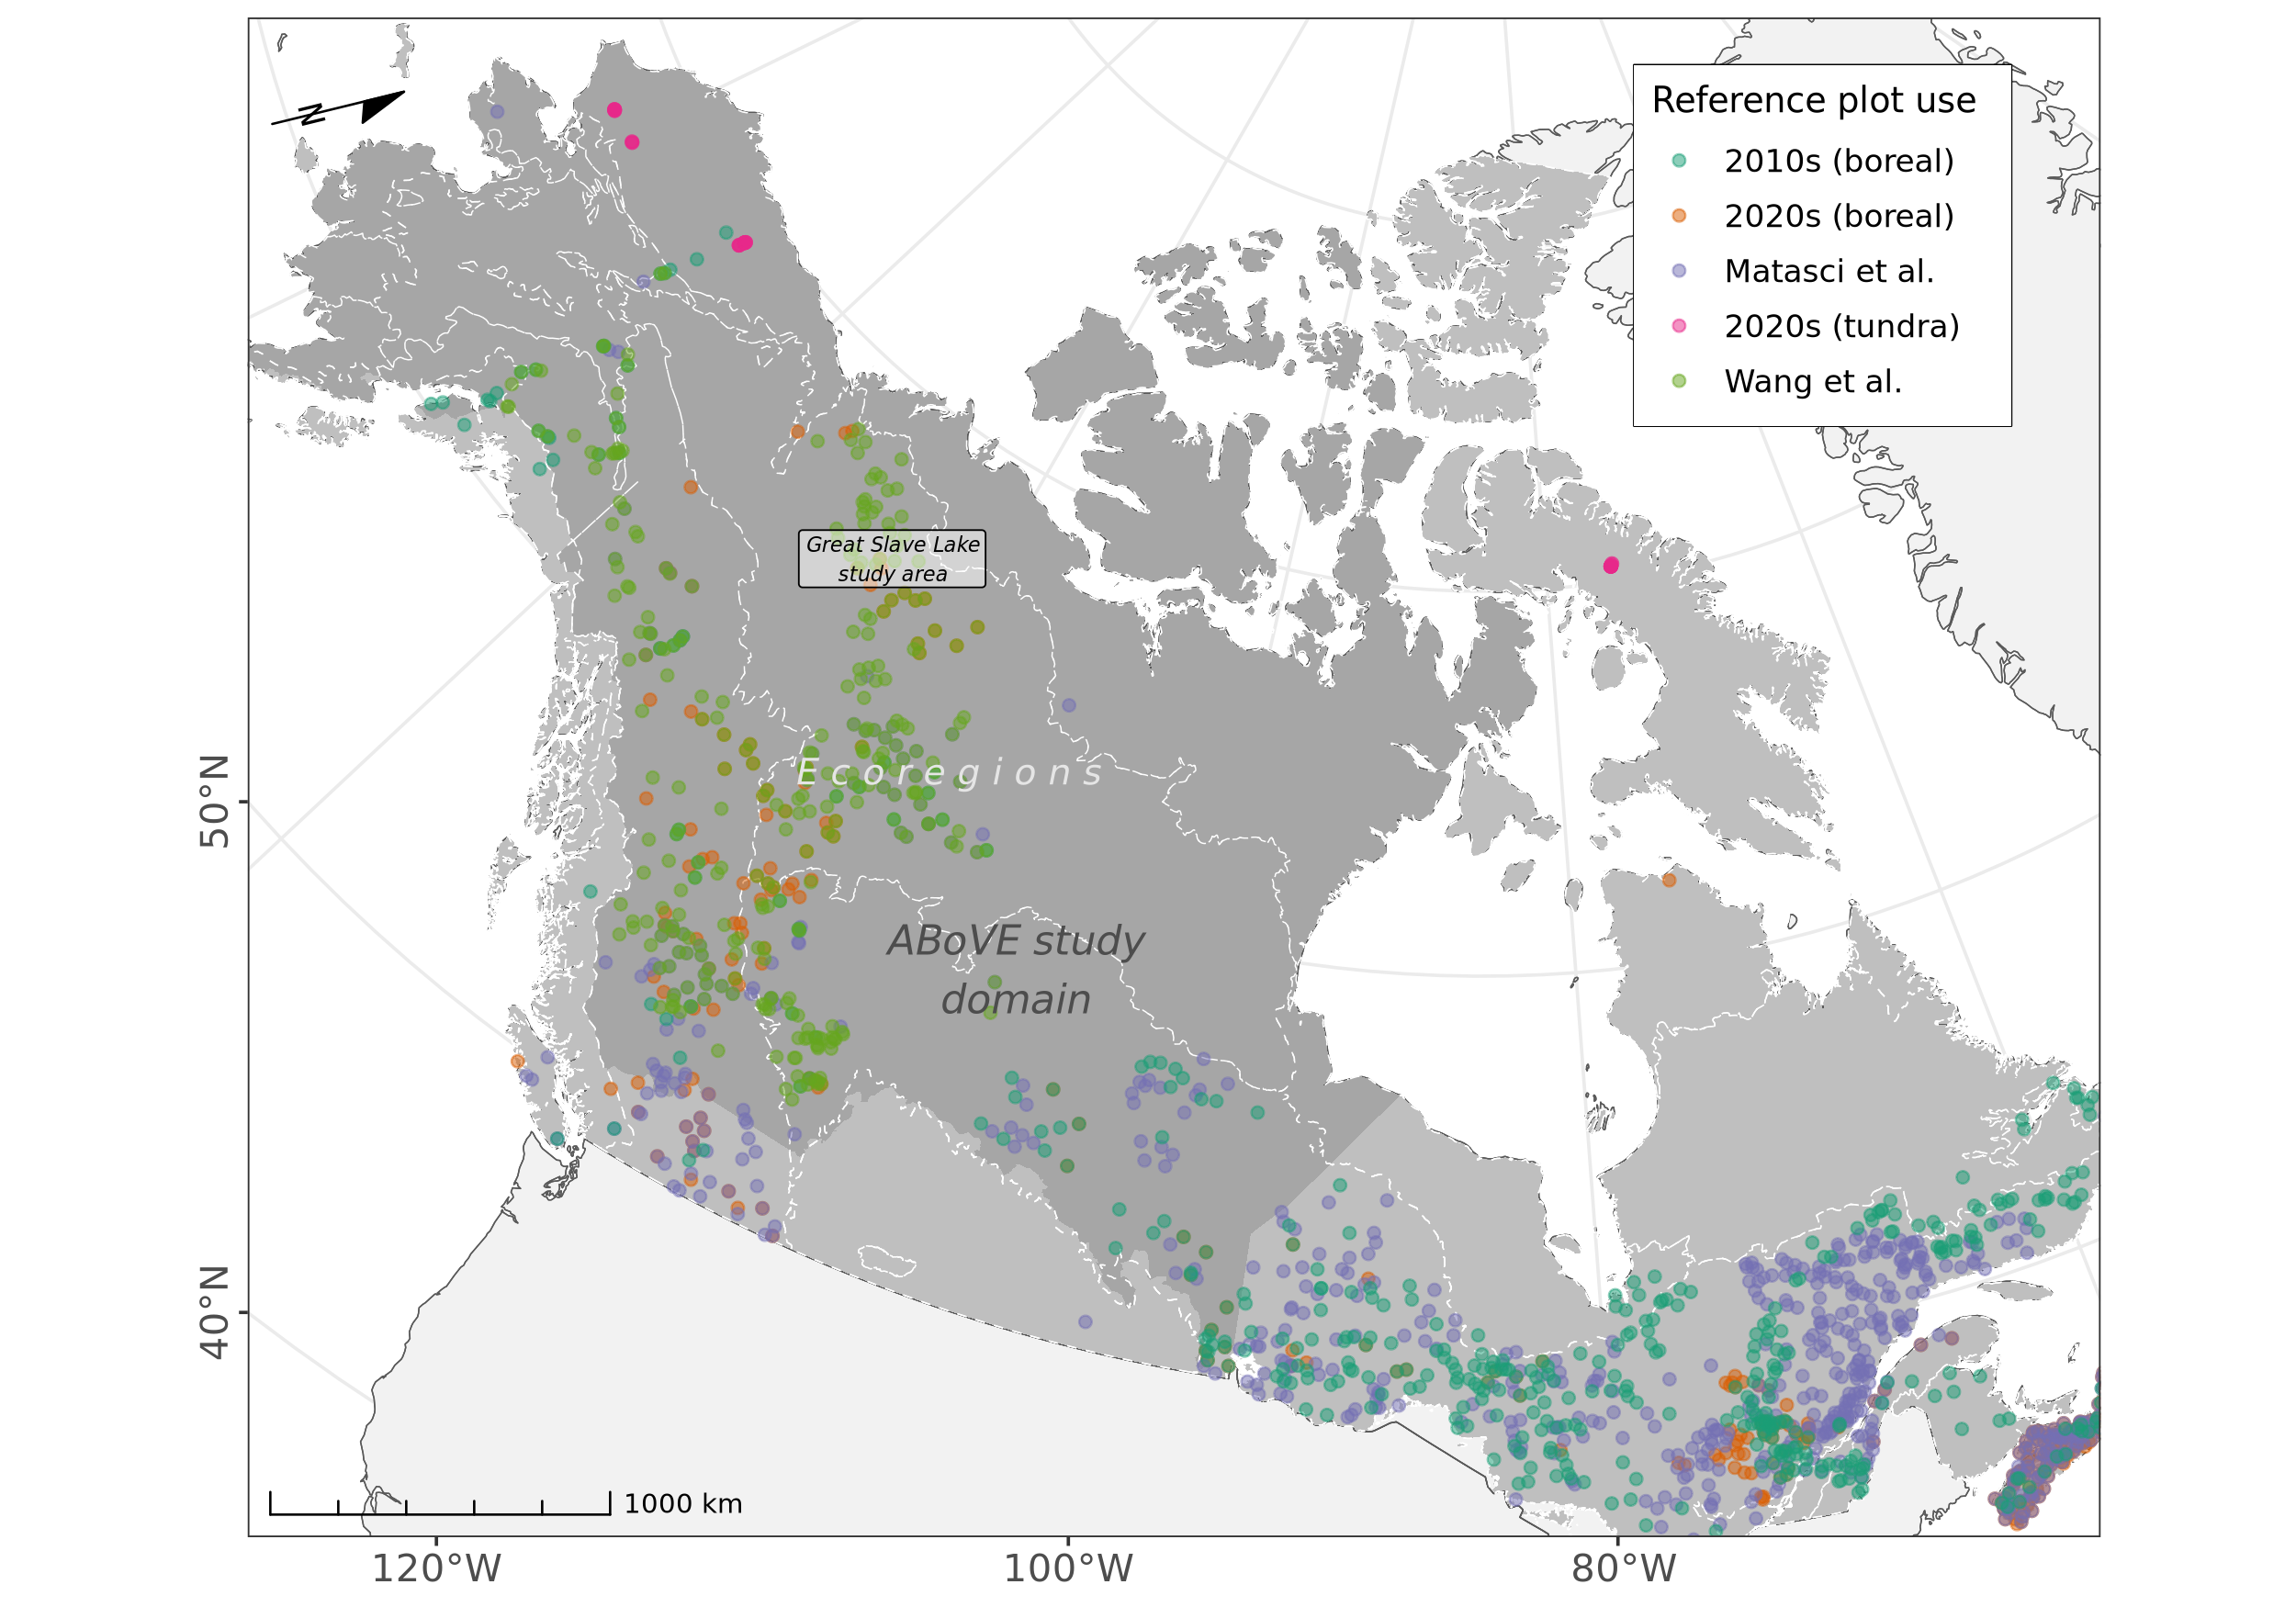

In [135]:
options(repr.plot.width = 10, repr.plot.height = 7, repr.plot.res = 250)

map_list = list(
    annotation_scale(location = "bl", style="ticks") ,
    annotation_north_arrow(location = "tl", which_north = "true", style=north_arrow_minimal())
    ,
    #geom_sf(data = above_domain, fill=NA, linetype = "dotted", linewidth=0.75),
    #geom_sf(data = above_domain, fill='grey70', alpha=0.5, linetype = "dashed", linewidth=0.5)
    geom_sf(data = above_domain, fill='grey65', alpha=1, color = NA),
    geom_sf(data = ecoregions, fill=NA, color='white', linetype = "dashed", size=4)
    )

map_study_domain = do_map_above_metaanalysis(ABOVE_DOMAIN = FALSE) + 
    
    #geom_sf(data=sample_n(lvis_footprints_trans,1000), aes(color=campaign, fill=campaign)) +
    #geom_sf(data=lvis_footprints_trans, aes(color=campaign, fill=campaign), linewidth=0.5) +
    scale_fill_brewer(palette = 'Dark2', aesthetics = c("colour", "fill")) + 
    map_list +
    GET_CUSTOM_ABOVE_METANALYSIS_MAP(disp_win_wgs84) +
    coord_sf(xlim = disp_win_coord[,'X'], ylim = disp_win_coord[,'Y'], crs = crs_canalb, expand = F)

map_study_domain

In [136]:
# dir.create(path = OUTDIR)
EXPORT_TIME_STR = format(Sys.time(), "_%Y%m%d")
ggsave(paste0(OUTDIR, paste0("/above_metaanalysis_study_domain",EXPORT_TIME_STR,".png")), map_study_domain, width = 10, height = 7, dpi = 250, bg='white')